In [ ]:
!pip install qutip

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 14.7 MB 8.9 MB/s 


In [ ]:
 from qutip import *
 import numpy as np
 import matplotlib.pyplot as plt
 import math
 import cmath

In [ ]:
bs1 = []
for i in range(3):
  bs1.append(basis(3,2-i))

print(bs1)

[Quantum object: dims = [[3], [1]], shape = (3, 1), type = ket
Qobj data =
[[0.]
 [0.]
 [1.]], Quantum object: dims = [[3], [1]], shape = (3, 1), type = ket
Qobj data =
[[0.]
 [1.]
 [0.]], Quantum object: dims = [[3], [1]], shape = (3, 1), type = ket
Qobj data =
[[1.]
 [0.]
 [0.]]]


In [ ]:
bs = []

for i in range(27):
    bs.append(basis(27,(26-i)))

#print(bs[2])

In [ ]:
I3 = 	qeye(3)
print(I3)

Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = True
Qobj data =
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [ ]:
density1 = bs1[0].proj()
print(density1)

Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = True
Qobj data =
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 1.]]


In [ ]:
density = tensor(density1, density1, density1)
#print(density)

In [ ]:
sigma12 = bs1[0]*(bs1[1].dag())
sigma21 = bs1[1]*(bs1[0].dag())
M = sigma12 + sigma21
#print(M)
M_squared = M*M

In [ ]:
J_12 = 10
J_23 = 10
H_dd = J_12*(tensor(sigma12,sigma21,I3) + tensor(sigma21,sigma12,I3)) + J_23*(tensor(I3,sigma12,sigma21) + tensor(I3,sigma21,sigma12))
print(H_dd)

Quantum object: dims = [[3, 3, 3], [3, 3, 3]], shape = (27, 27), type = oper, isherm = True
Qobj data =
[[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. 10.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. 10.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  

In [ ]:
psi0 = tensor(bs1[0],bs1[0],bs1[0])
print(psi0)

Quantum object: dims = [[3, 3, 3], [1, 1, 1]], shape = (27, 1), type = ket
Qobj data =
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]]


In [ ]:
times = np.linspace(0, 10, 100)


In [ ]:
k1 = 0.5
k2 = 1
n = 1j
mn1 = tensor(bs1[1].proj(),I3,I3)
mn2 = tensor(I3,bs1[1].proj(),I3)
mn3 = tensor(I3,I3,bs1[1].proj())
ps1 = tensor(bs1[2].proj(),I3,I3)
ps2 = tensor(I3,bs1[2].proj(),I3)
ps3 = tensor(I3,I3,bs1[2].proj())
damage1 = n*(k1*mn1)/2
recovery1 = n*(k2*ps1)/2
damage2 = n*(k1*mn2)/2
recovery2 = n*(k2*ps2)/2
damage3 = n*(k1*mn3)/2
recovery3 = n*(k2*ps3)/2
H_eff = H_dd - damage1 - damage2 - damage3 - recovery1 - recovery2 - recovery3

In [ ]:
omega = 5
H_eff_1 = H_eff + (omega/2)*(tensor(sigma12+sigma21,I3,I3))
#print(H_eff_1)

/usr/local/lib/python3.7/dist-packages/matplotlib/cbook/__init__.py:1317: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


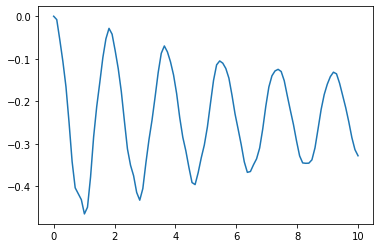

In [ ]:
result7 = mesolve(H_eff_1, psi0, times, [], [(tensor(sigma21,I3,I3)*tensor(I3,I3,sigma12))])
plt.plot(result7.times, result7.expect[0])
#print(result7.expect)

In [ ]:
sigma32 = bs1[2]*(bs1[1].dag())
sigma23 = bs1[1]*(bs1[2].dag())
sigma13 = bs1[0]*(bs1[2].dag())
sigma31 = bs1[2]*(bs1[0].dag())
#J1_32 = tensor(math.sqrt(k1)*sigma32,I3,I3)
#J1_32_psi = J1_32*(result5.states)
#J1_32_psi.append(J1_32*(result5.states))
#print(J1_32_psi)

In [ ]:
J1_32 = tensor(math.sqrt(k1)*sigma32,I3,I3)
J2_32 = tensor(I3,math.sqrt(k1)*sigma32,I3)
J3_32 = tensor(I3,I3,math.sqrt(k1)*sigma32)
J1_13 = tensor(math.sqrt(k2)*sigma13,I3,I3)
J2_13 = tensor(I3,math.sqrt(k2)*sigma13,I3)
J3_13 = tensor(I3,I3, math.sqrt(k2)*sigma13)
print(sigma32)

#J1_32_psi.append(J1_32*(result5.states))
#print(J1_32_psi)


Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = False
Qobj data =
[[0. 1. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


In [ ]:
delta_t = 0.001

In [ ]:
times_new = np.arange(0,100,delta_t)
print(times_new)


[0.0000e+00 1.0000e-03 2.0000e-03 ... 9.9997e+01 9.9998e+01 9.9999e+01]


In [ ]:
#psi_updated = []
c = 0
#c1 = 0
del_p = []
jump_where = []
jump_where1 = []
jump_which = []
psi_t = psi0
#psi_updated.append(psi_t)
for i in times_new :
  #psi_t = psi0
  expt = expect(H_eff_1-(H_eff_1.dag()),psi_t)
  delta_p = 1j*(delta_t*expt)
  epsilon = np.random.uniform(low = 0.0, high = 1.0, size = None)
  #psi_updated.append(psi_t)
  if (delta_p.real < epsilon) :
    psi_dt = (1 - 1j*(H_eff_1*delta_t))*psi_t/(math.sqrt(1-delta_p.real))
    c = c+1
    psi_t = psi_dt
    #psi_updated.append(psi_t)
  elif (delta_p.real >= epsilon) :
    #c1 = c1 + 1
    jump_where.append(i)
    #kl.append(delta_p)
    #op.append(epsilon)
    delta = np.random.uniform(low = 0.0, high = 1.0, size = None)
    delta_p1_32 = (expect(J1_32.dag()*J1_32,psi_t))*delta_t
    delta_p2_32 = (expect(J2_32.dag()*J2_32,psi_t))*delta_t
    delta_p3_32 = (expect(J3_32.dag()*J3_32,psi_t))*delta_t
    delta_p1_13 = (expect(J1_13.dag()*J1_13,psi_t))*delta_t
    delta_p2_13 = (expect(J2_13.dag()*J2_13,psi_t))*delta_t
    delta_p3_13 = (expect(J3_13.dag()*J3_13,psi_t))*delta_t
    del_p = np.array([delta_p1_32, delta_p2_32, delta_p3_32, delta_p1_13, delta_p2_13, delta_p3_13])
    #kl.append(del_p)
    J = [J1_32, J2_32, J3_32, J1_13, J2_13, J3_13]
    count = np.count_nonzero(del_p, axis=None)
    ab = np.linspace(0,1,count+1)
    zero_where = np.where(del_p != 0)[0]
    #prob = delta_p1_32+delta_p2_32+delta_p3_32+delta_p1_13+delta_p2_13+delta_p3_13
    for l in range(count) :
      if (delta >= ab[l] and delta < ab[l+1]) :
        psi_dt = ((J[zero_where[l]])*psi_t)/(cmath.sqrt(del_p[zero_where[l]]/delta_t))
        jump_where1.append(ab[l])
        jump_which.append(J[zero_where[l]])
        break
    psi_t = psi_dt
    #psi_updated.append(psi_t)
    #psi_t = psi0
  #psi_t = psi_dt
  #psi_updated.append(psi_t)


In [ ]:

jump = np.zeros(100000)
for iter in range(len(jump_where)) :
  for iter1 in range(6) :
    if ((jump_which[iter] == J[iter1]) and (iter1 < 3)) :
      bn = int(jump_where[iter]*1000)
      bn_count = jump[bn]
      jump[bn:]+= 1
      break
    elif ((jump_which[iter] == J[iter1]) and (iter1 >= 3)) :
      cn = int(jump_where[iter]*1000)
      jump[cn:]-= 1
      break

print(jump)



[0. 0. 0. ... 1. 1. 1.]


In [ ]:
jump_time = (np.count_nonzero(jump, axis=None))*delta_t
print(jump_time)
print("Damaged state percentage",jump_time,"%")
#print(np.count_nonzero(jump==0))

48.659
Damaged state percentage 48.659 %


In [ ]:
jump_nonzero = jump[np.where(jump!=0)]
print(len(jump_where))

127


In [ ]:
j1 = ((np.count_nonzero(jump==1))*delta_t)
j2 = ((np.count_nonzero(jump==2))*delta_t)*2
j3 = ((np.count_nonzero(jump==3))*delta_t)*3
j = j1+j2+j3
print(j)

78.754


In [ ]:
print("Damaged state area in percentage",j/3,"%")

Damaged state area in percentage 26.251333333333335 %


Text(0.5, 1.0, 'Telegraph diagram of network state')

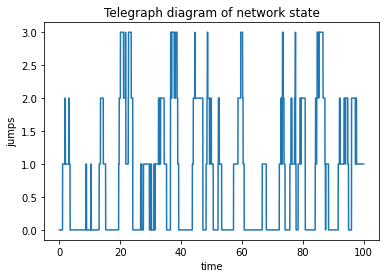

In [ ]:
plt.plot(times_new, jump)
plt.xlabel('time')
plt.ylabel('jumps')
plt.title("Telegraph diagram of network state")
#plt.xlim([0,15])

In [ ]:
state1 = np.zeros(100000)
state2 = np.zeros(100000)
state3 = np.zeros(100000)
for i in range(len(jump_where)) :
  if (jump_which[i] == J[0] or jump_which[i] == J[3]) :
    bn = int(jump_where[i]*1000)
    state1[bn]+= 1
  elif (jump_which[i] == J[1] or jump_which[i] == J[4]) :
    bn = int(jump_where[i]*1000)
    state2[bn]+= 1
  else :
    bn = int(jump_where[i]*1000)
    state3[bn]+= 1


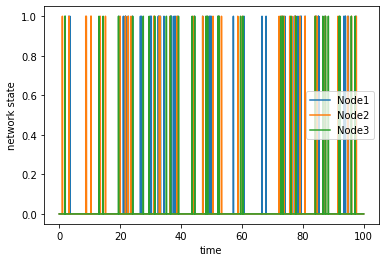

In [ ]:
plt.plot(times_new, state1, times_new, state2, times_new, state3)
plt.xlabel('time')
plt.ylabel('network state')
#plt.title("Telegraph diagram of network state")
#plt.xlim([0,12])
plt.legend(['Node1', 'Node2', 'Node3'])

In [ ]:
H_eff_2 = H_eff + (omega/2)*(tensor(I3,sigma12+sigma21,I3))
c = 0
#c1 = 0
del_p = []
jump_where = []
jump_where1 = []
jump_which = []
psi_t = psi0
#psi_updated.append(psi_t)
for i in times_new :
  #psi_t = psi0
  expt = expect(H_eff_2-(H_eff_2.dag()),psi_t)
  delta_p = 1j*(delta_t*expt)
  epsilon = np.random.uniform(low = 0.0, high = 1.0, size = None)
  #psi_updated.append(psi_t)
  if (delta_p.real < epsilon) :
    psi_dt = (1 - 1j*(H_eff_2*delta_t))*psi_t/(math.sqrt(1-delta_p.real))
    c = c+1
    psi_t = psi_dt
    #psi_updated.append(psi_t)
  elif (delta_p.real >= epsilon) :
    #c1 = c1 + 1
    jump_where.append(i)
    #kl.append(delta_p)
    #op.append(epsilon)
    delta = np.random.uniform(low = 0.0, high = 1.0, size = None)
    delta_p1_32 = (expect(J1_32.dag()*J1_32,psi_t))*delta_t
    delta_p2_32 = (expect(J2_32.dag()*J2_32,psi_t))*delta_t
    delta_p3_32 = (expect(J3_32.dag()*J3_32,psi_t))*delta_t
    delta_p1_13 = (expect(J1_13.dag()*J1_13,psi_t))*delta_t
    delta_p2_13 = (expect(J2_13.dag()*J2_13,psi_t))*delta_t
    delta_p3_13 = (expect(J3_13.dag()*J3_13,psi_t))*delta_t
    del_p = np.array([delta_p1_32, delta_p2_32, delta_p3_32, delta_p1_13, delta_p2_13, delta_p3_13])
    #kl.append(del_p)
    J = [J1_32, J2_32, J3_32, J1_13, J2_13, J3_13]
    count = np.count_nonzero(del_p, axis=None)
    ab = np.linspace(0,1,count+1)
    zero_where = np.where(del_p != 0)[0]
    #prob = delta_p1_32+delta_p2_32+delta_p3_32+delta_p1_13+delta_p2_13+delta_p3_13
    for l in range(count) :
      if (delta >= ab[l] and delta < ab[l+1]) :
        psi_dt = ((J[zero_where[l]])*psi_t)/(cmath.sqrt(del_p[zero_where[l]]/delta_t))
        jump_where1.append(ab[l])
        jump_which.append(J[zero_where[l]])
        break
    psi_t = psi_dt

In [ ]:
jump = np.zeros(100000)
for iter in range(len(jump_where)) :
  for iter1 in range(6) :
    if ((jump_which[iter] == J[iter1]) and (iter1 < 3)) :
      bn = int(jump_where[iter]*1000)
      bn_count = jump[bn]
      jump[bn:]+= 1
      break
    elif ((jump_which[iter] == J[iter1]) and (iter1 >= 3)) :
      cn = int(jump_where[iter]*1000)
      jump[cn:]-= 1
      break

print(jump)




[0. 0. 0. ... 1. 1. 1.]


Text(0.5, 1.0, 'Telegraph diagram of network state')

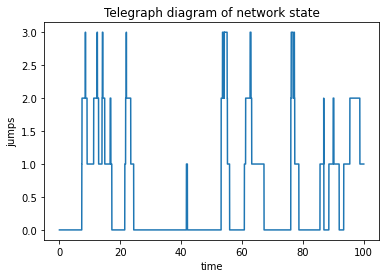

In [ ]:
plt.plot(times_new, jump)
plt.xlabel('time')
plt.ylabel('jumps')
plt.title("Telegraph diagram of network state")
#plt.xlim([0,15])

In [ ]:
jump_time1 = (np.count_nonzero(jump, axis=None))*delta_t
print(jump_time1)
print("Damaged state percentage",jump_time1,"%")

36.284
Damaged state percentage 36.284 %


In [ ]:
j1 = ((np.count_nonzero(jump==1))*delta_t)
j2 = ((np.count_nonzero(jump==2))*delta_t)*2
j3 = ((np.count_nonzero(jump==3))*delta_t)*3
j = j1+j2+j3
print(j)

53.75


In [ ]:
print("Damaged state area in percentage",j/3,"%")

Damaged state area in percentage 17.916666666666668 %


In [ ]:

state1 = np.zeros(100000)
state2 = np.zeros(100000)
state3 = np.zeros(100000)
for i in range(len(jump_where)) :
  if (jump_which[i] == J[0] or jump_which[i] == J[3]) :
    bn = int(jump_where[i]*1000)
    state1[bn]+= 1
  elif (jump_which[i] == J[1] or jump_which[i] == J[4]) :
    bn = int(jump_where[i]*1000)
    state2[bn]+= 1
  else :
    bn = int(jump_where[i]*1000)
    state3[bn]+= 1


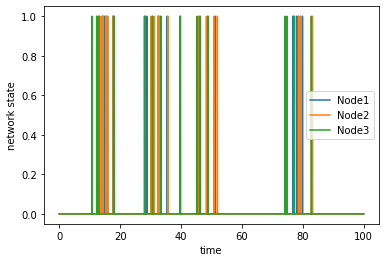

In [ ]:
plt.plot(times_new, state1, times_new, state2, times_new, state3)
plt.xlabel('time')
plt.ylabel('network state')
#plt.title("Telegraph diagram of network state")
#plt.xlim([0,12])
plt.legend(['Node1', 'Node2', 'Node3'])

In [ ]:
ar_omega2_percent1 = np.array([27.093,25.044,23.796,25.311,26.251])
ar_omega2_percent2 = np.array([11.856,15.653,6.371,10.165,17.916])
ar_omega1_percent1 = np.array([56.3386,52.214,57.941,65.2044,69.1768])
ar_omega1_percent2 = np.array([52.214,61.3796,57.162,57.6410,67.7856])

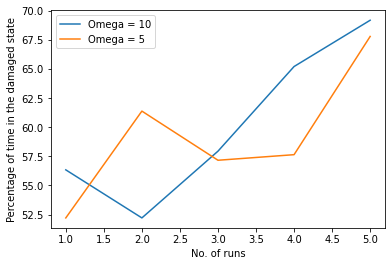

In [ ]:
runs = np.arange(1,6,1)
plt.plot(runs,ar_omega1_percent1,runs,ar_omega1_percent2)
plt.xlabel("No. of runs")
plt.ylabel("Percentage of time in the damaged state")
plt.legend(["Omega = 10","Omega = 5"])

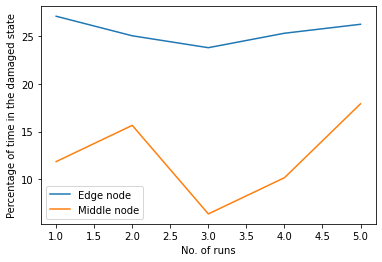

In [ ]:
plt.plot(runs,ar_omega2_percent1,runs,ar_omega2_percent2)
plt.xlabel("No. of runs")
plt.ylabel("Percentage of time in the damaged state")
plt.legend(["Edge node","Middle node"])

In [ ]:
times_new1 = np.arange(0,10,delta_t)

In [ ]:
data = mcsolve(H_eff, psi0, times_new1, [J1_32, J2_32, J3_32, J1_13, J2_13, J3_13], [tensor(sigma21,I3,I3)*tensor(I3,I3,sigma12)])

10.0%. Run time: 121.68s. Est. time left: 00:00:18:15
20.0%. Run time: 241.55s. Est. time left: 00:00:16:06
30.0%. Run time: 359.62s. Est. time left: 00:00:13:59
40.0%. Run time: 477.56s. Est. time left: 00:00:11:56
50.0%. Run time: 596.04s. Est. time left: 00:00:09:56
60.0%. Run time: 714.85s. Est. time left: 00:00:07:56
70.0%. Run time: 834.18s. Est. time left: 00:00:05:57
80.0%. Run time: 953.24s. Est. time left: 00:00:03:58
90.0%. Run time: 1071.98s. Est. time left: 00:00:01:59
100.0%. Run time: 1190.37s. Est. time left: 00:00:00:00
Total run time: 1190.51s


In [ ]:
data1 = mcsolve(H_eff, psi0, times_new1, [J1_32, J2_32, J3_32, J1_13, J2_13, J3_13], [tensor(sigma21,I3,I3)])

10.0%. Run time: 121.92s. Est. time left: 00:00:18:17
20.0%. Run time: 240.88s. Est. time left: 00:00:16:03
30.0%. Run time: 361.34s. Est. time left: 00:00:14:03
40.0%. Run time: 483.52s. Est. time left: 00:00:12:05
50.0%. Run time: 603.60s. Est. time left: 00:00:10:03
60.0%. Run time: 724.15s. Est. time left: 00:00:08:02
70.0%. Run time: 847.52s. Est. time left: 00:00:06:03
80.0%. Run time: 967.32s. Est. time left: 00:00:04:01
90.0%. Run time: 1087.41s. Est. time left: 00:00:02:00
100.0%. Run time: 1206.20s. Est. time left: 00:00:00:00
Total run time: 1206.28s


/usr/local/lib/python3.7/dist-packages/matplotlib/cbook/__init__.py:1317: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Expectation values')

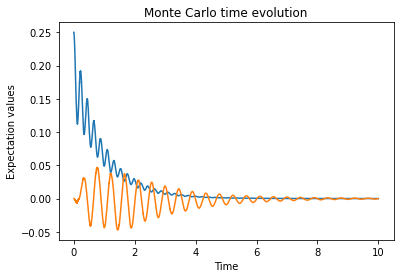

In [ ]:
plt.plot(times_new1, data.expect[0], times_new1, data1.expect[0])
plt.title('Monte Carlo time evolution')
plt.xlabel('Time')
plt.ylabel('Expectation values')
#plt.xlim([0, 2])
#plt.legend(("cavity photon number", "atom excitation probability"))


In [ ]:
ps = []
lk = []
nm = []
c2 = 0
psi_t1 = psi0
for u in times_new :
  #psi_t = psi0
  expt1 = expect(H_eff-(H_eff.dag()),psi_t1)
  delta_p1 = 1j*(delta_t*expt1)
  epsilon1 = np.random.uniform(low = 0.0, high = 0.000001)
  ps.append(psi_t1)
  lk.append(delta_p1)
  nm.append(epsilon1)
  if (delta_p1.real >= epsilon1) :
    c2 = c2 + 1
    delta1 = np.random.uniform(low = 0.0, high = 0.00001 , size = None)
    delta_p1_32 = -(expect(J1_32.dag()*J1_32,psi_t1))*delta_t
    delta_p2_32 = -(expect(J2_32.dag()*J2_32,psi_t1))*delta_t
    delta_p3_32 = -(expect(J3_32.dag()*J3_32,psi_t1))*delta_t
    delta_p1_13 = -(expect(J1_13.dag()*J1_13,psi_t1))*delta_t
    delta_p2_13 = -(expect(J2_13.dag()*J2_13,psi_t1))*delta_t
    delta_p3_13 = -(expect(J3_13.dag()*J3_13,psi_t1))*delta_t
    del_p1 = np.array([delta_p1_32, delta_p2_32, delta_p3_32, delta_p1_13, delta_p2_13, delta_p3_13])
    #kl.append(del_p)
    J1 = [J1_32, J2_32, J3_32, J1_13, J2_13, J3_13]
    count1 = np.count_nonzero(del_p1, axis=None)
    ab1 = np.linspace(0,1,count1+1)
    zero_where1 = np.where(del_p1!= 0)[0]
    prob = delta_p1_32+delta_p2_32+delta_p3_32+delta_p1_13+delta_p2_13+delta_p3_13
    for s in range(count) :
      if (delta1 >= ab1[s] and delta1 < ab1[s+1]) :
        psi_dt1 = ((J1[zero_where1[s]])*psi_t1)/(cmath.sqrt(del_p1[zero_where1[s]]/delta_t))

    psi_t1 = psi_dt1

In [ ]:
print(lk[:10])
print(nm[:10])

[(7.5e-05+0j), (-5.0000000000000016e-05+0j), (-5.0000000000000016e-05+0j), (-5.0000000000000016e-05+0j), (-5.0000000000000016e-05+0j), (-5.0000000000000016e-05+0j), (-5.0000000000000016e-05+0j), (-5.0000000000000016e-05+0j), (-5.0000000000000016e-05+0j), (-5.0000000000000016e-05+0j)]
[3.482389518172667e-07, 5.655912149636253e-07, 4.929324360752599e-07, 3.4203378067554355e-09, 3.361398332373202e-07, 2.2488251520975443e-07, 7.264205013689576e-07, 7.485035659777955e-07, 5.664580076505535e-07, 6.610487058500227e-07]


In [ ]:
print(c2)

1


In [ ]:
#rl = psi_dt.real/(math.sqrt(1-delta_p))
    #im = psi_dt.imag/(math.sqrt(1-delta_p))
    #nm = psi_t.norm()

In [ ]:
expt1 = expect((H_eff-(H_eff.dag())),psi0)
print(psi0.dag()*(H_eff-(H_eff.dag()))*psi0)
delta_p1 = 1j*(delta_t*expt1)
print(expt1,delta_p1)
epsilon = np.random.uniform(low = 0.0, high = 0.001, size = None)
print(epsilon)

Quantum object: dims = [[1], [1]], shape = (1, 1), type = bra
Qobj data =
[[0.-0.75j]]
-0.7499999999999999j (0.0007499999999999999+0j)
4.151435046801699e-05


In [ ]:
#print(expect(H_eff-H_eff.dag(),psi0))
print(c)
print(c1)
ty = (1 - 1j*H_eff*delta_t)*psi0
print(cmath.sqrt((ty.dag()*ty)[0]))
expt1 = expect(H_eff-H_eff.dag(),psi0)
delta_p1 = 1j*(delta_t*expt1)
print(cmath.sqrt(1-delta_p1).real)

99999
1
(0.9999643228010687+0j)
0.9999624992968487


In [ ]:
print(psi_updated[10000:10500])


[Quantum object: dims = [[3, 3, 3], [1, 1, 1]], shape = (27, 1), type = ket
Qobj data =
[[ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.23385266j]
 [-0.30027745+0.j        ]
 [ 0.        +0.j        ]
 [ 0.09136198+0.29772282j]
 [-0.38236566+0.1170539j ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.09136198+0.29772282j]
 [-0.38236566+0.1170539j ]
 [ 0.        +0.j        ]
 [ 0.        -0.38556749j]
 [ 0.49508   +0.j        ]], Quantum object: dims = [[3, 3, 3], [1, 1, 1]], shape = (27, 1), type = ket
Qobj data =
[[ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        

In [ ]:
et = expect((tensor(sigma12,I3,I3)*tensor(I3,sigma21,I3)),psi_updated[11000])
print(et)
print(psi_updated[11000])

0j
Quantum object: dims = [[3, 3, 3], [1, 1, 1]], shape = (27, 1), type = ket
Qobj data =
[[ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.35683916j]
 [-0.46978573+0.j        ]
 [ 0.        +0.j        ]
 [ 0.42583615-0.23916636j]
 [ 0.31446087+0.56084312j]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]]


In [ ]:
print(expectation[10500:11000])

[0.25666732+0.j 0.25666683+0.j 0.25666633+0.j 0.25666583+0.j
 0.25666533+0.j 0.25666483+0.j 0.25666434+0.j 0.25666384+0.j
 0.25666334+0.j 0.25666284+0.j 0.25666234+0.j 0.25666184+0.j
 0.25666134+0.j 0.25666084+0.j 0.25666034+0.j 0.25665984+0.j
 0.25665934+0.j 0.25665884+0.j 0.25665833+0.j 0.25665783+0.j
 0.25665733+0.j 0.25665683+0.j 0.25665633+0.j 0.25665583+0.j
 0.25665532+0.j 0.25665482+0.j 0.25665432+0.j 0.25665381+0.j
 0.25665331+0.j 0.25665281+0.j 0.2566523 +0.j 0.2566518 +0.j
 0.2566513 +0.j 0.25665079+0.j 0.25665029+0.j 0.25664978+0.j
 0.25664928+0.j 0.25664877+0.j 0.25664827+0.j 0.25664776+0.j
 0.25664726+0.j 0.25664675+0.j 0.25664625+0.j 0.25664574+0.j
 0.25664523+0.j 0.25664473+0.j 0.25664422+0.j 0.25664371+0.j
 0.25664321+0.j 0.2566427 +0.j 0.25664219+0.j 0.25664168+0.j
 0.25664118+0.j 0.25664067+0.j 0.25664016+0.j 0.25663965+0.j
 0.25663914+0.j 0.25663863+0.j 0.25663812+0.j 0.25663761+0.j
 0.2566371 +0.j 0.25663659+0.j 0.25663608+0.j 0.25663557+0.j
 0.25663506+0.j 0.256634

/usr/local/lib/python3.7/dist-packages/matplotlib/cbook/__init__.py:1317: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


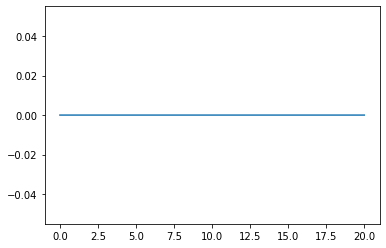

In [ ]:
gh1 = expect((tensor(sigma12,I3,I3)*tensor(I3,sigma21,I3)),psi_updated)
#print(gh1*re)
plt.plot(times_new, gh1)
#plt.xlim([0, 0.1])
#plt.ylim([-1e-3, 1e-3])

In [ ]:
for lk in range(count+1) :
      if (p>=ab[lk] and p<ab[lk+1]) :
        psi_dt = ((J[zero_where[lk]])*psi_t)/(cmath.sqrt(del_p[zero_where[lk]]/delta_t))

print(psi0)
print(psi_t)
print(psi_dt)
print(delta)
print(del_p)
print(del_p[zero_where[l]])

Quantum object: dims = [[3, 3, 3], [1, 1, 1]], shape = (27, 1), type = ket
Qobj data =
[[0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        -0.70710678j]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.70710678+0.j        ]]
[[0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [

In [ ]:
zero_where = np.where(del_p != 0)[0]
m = zero_where[0]
#print(J[zero_where[1]])


In [ ]:
plt.plot(result7.times, result7.expect[0]*re)




In [ ]:
psi_t = expect(H_eff-H_eff.dag(),psi0)
print(psi_t)

-1.2499999999999998j
